# Word Vectors: From Sparse Representations to Dense Semantic Spaces

This notebook is the second notebook in the **AI NLP LLM Notes** learning path.

The previous notebook introduced TF-IDF, a strong and interpretable representation for lexical search and text analytics. This notebook continues naturally from that foundation and explains why NLP systems moved from sparse text representations toward **dense word vectors** that can encode semantic relationships.

# Introduction

TF-IDF represents documents as numerical vectors where each dimension corresponds to a word or phrase from a vocabulary. This is useful, but it creates **sparse vectors**: most entries are zero because each document contains only a small fraction of the vocabulary.

Bag of Words and TF-IDF are effective for exact lexical matching, but they do not understand meaning. To a sparse vector model, `doctor` and `physician` are different features, even though humans understand that they are closely related.

Word vectors were introduced to represent words in a dense semantic space, where words with similar meanings can appear close together.

## Why TF-IDF is not enough

Sparse methods treat terms as independent vocabulary entries. This creates a semantic gap:

- `doctor` and `physician` are medically related, but TF-IDF sees different columns.
- `car` and `automobile` describe the same concept, but they do not overlap lexically.
- `purchase` and `buy` express similar intent, but they are separate tokens.
- `movie` and `film` are often interchangeable, but sparse vectors do not know this.

This matters in search, recommendations, chatbots, and retrieval systems. A user may ask a question using different words than the documents use.

The small example below shows why exact word overlap is fragile. The two sentences have almost the same meaning, but they share very few content words.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from sklearn.metrics.pairwise import cosine_similarity
except ModuleNotFoundError:

    def cosine_similarity(matrix_a, matrix_b):
        """Compute cosine similarity when scikit-learn is unavailable."""
        matrix_a = np.asarray(matrix_a, dtype=float)
        matrix_b = np.asarray(matrix_b, dtype=float)
        numerator = matrix_a @ matrix_b.T
        norm_a = np.linalg.norm(matrix_a, axis=1, keepdims=True)
        norm_b = np.linalg.norm(matrix_b, axis=1, keepdims=True).T
        return numerator / np.clip(norm_a * norm_b, a_min=1e-12, a_max=None)

In [2]:
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.facecolor": "#FAFAFA",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "font.family": "DejaVu Sans",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
        "xtick.color": "#222222",
        "ytick.color": "#222222",
    }
)

PRIMARY_COLOR = "#2F6F9F"
SECONDARY_COLOR = "#D95F59"
ACCENT_COLOR = "#3A9D7C"
NEUTRAL_COLOR = "#6B7280"

In [3]:
def tokenize(text):
    """Tokenize text with a simple lowercase whitespace strategy."""
    cleaned_text = text.lower().replace(".", "").replace(",", "")
    return cleaned_text.split()


sentence_a = "The doctor purchased a car."
sentence_b = "The physician bought an automobile."

tokens_a = set(tokenize(sentence_a))
tokens_b = set(tokenize(sentence_b))
shared_tokens = tokens_a.intersection(tokens_b)
union_tokens = tokens_a.union(tokens_b)
jaccard_similarity = len(shared_tokens) / len(union_tokens)

lexical_overlap = pd.DataFrame(
    {
        "sentence": ["A", "B"],
        "text": [sentence_a, sentence_b],
        "tokens": [sorted(tokens_a), sorted(tokens_b)],
    }
)

display(lexical_overlap)
print(f"Shared tokens: {sorted(shared_tokens)}")
print(f"Jaccard similarity: {jaccard_similarity:.2f}")

,sentence,text,tokens
0,A,The doctor purchased a car.,"[a, car, doctor, purchased, the]"
1,B,The physician bought an automobile.,"[an, automobile, bought, physician, the]"


Shared tokens: ['the']
Jaccard similarity: 0.11


## What is a Word Vector?

A **word vector** is a fixed-length numerical representation of a word. Unlike sparse vectors, dense word vectors usually have no direct one-to-one mapping between a dimension and an individual word.

Word vectors are:

- **dense**: most values are non-zero,
- **fixed-length**: every word is represented by the same number of dimensions,
- **learned representations**: usually learned from large text corpora,
- **semantic**: words used in similar contexts tend to receive similar vectors.

Conceptually, a word vector places words inside a geometric space where distance and direction can encode relationships.

## Sparse vs Dense Representations

Sparse and dense representations solve different problems. Sparse vectors are transparent and strong for lexical matching. Dense vectors are less interpretable dimension-by-dimension, but they generalize better when meaning matters.

The diagram below summarizes the structural difference. Sparse vectors are wide and mostly empty; dense vectors are compact and information-rich.

In [4]:
comparison_table = pd.DataFrame(
    {
        "Aspect": [
            "Dimension",
            "Memory",
            "Interpretability",
            "Semantic understanding",
            "Performance",
            "Generalization",
            "Visualization",
        ],
        "Sparse representations": [
            "Often vocabulary-sized, sometimes tens of thousands of columns",
            "Mostly zeros; efficient sparse storage is usually required",
            "High, because each feature maps to a visible term",
            "Limited, because synonyms are treated as unrelated features",
            "Strong for exact lexical matching and transparent baselines",
            "Weak when users and documents use different vocabulary",
            "Difficult directly because dimensionality is very high",
        ],
        "Dense representations": [
            "Usually tens to thousands of dimensions",
            "Compact fixed-size vectors with many non-zero values",
            "Lower, because dimensions are learned and distributed",
            "Stronger, because similar words can appear close together",
            "Strong for semantic search and many downstream NLP tasks",
            "Better when semantic similarity matters",
            "Often visualized after dimensionality reduction",
        ],
    }
)

display(comparison_table)

,Aspect,Sparse representations,Dense representations
0,Dimension,"Often vocabulary-sized, sometimes tens of thou...",Usually tens to thousands of dimensions
1,Memory,Mostly zeros; efficient sparse storage is usua...,Compact fixed-size vectors with many non-zero ...
2,Interpretability,"High, because each feature maps to a visible term","Lower, because dimensions are learned and dist..."
3,Semantic understanding,"Limited, because synonyms are treated as unrel...","Stronger, because similar words can appear clo..."
4,Performance,Strong for exact lexical matching and transpar...,Strong for semantic search and many downstream...
5,Generalization,Weak when users and documents use different vo...,Better when semantic similarity matters
6,Visualization,Difficult directly because dimensionality is v...,Often visualized after dimensionality reduction


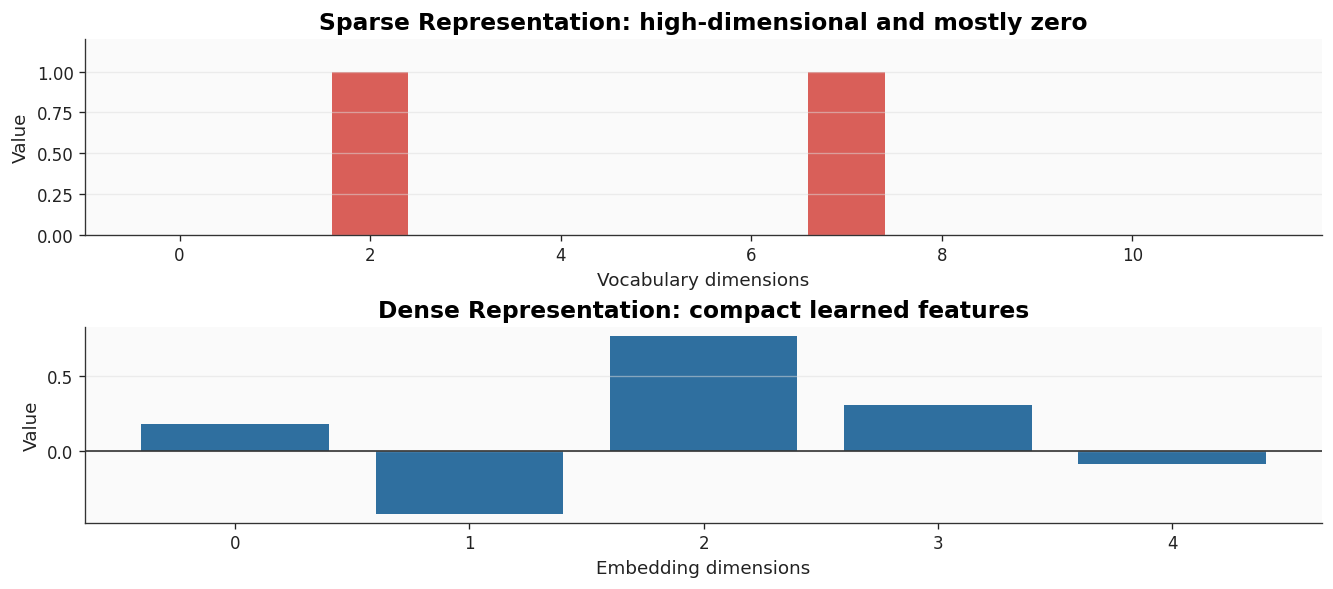

In [5]:
def plot_sparse_dense_diagram():
    """Draw a conceptual sparse-versus-dense representation diagram."""
    sparse_vector = np.array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0])
    dense_vector = np.array([0.18, -0.42, 0.77, 0.31, -0.09])

    fig, axes = plt.subplots(2, 1, figsize=(11, 4.8), constrained_layout=True)

    axes[0].bar(
        range(len(sparse_vector)),
        sparse_vector,
        color=[SECONDARY_COLOR if value else "#D1D5DB" for value in sparse_vector],
    )
    axes[0].set_title("Sparse Representation: high-dimensional and mostly zero")
    axes[0].set_xlabel("Vocabulary dimensions")
    axes[0].set_ylabel("Value")
    axes[0].set_ylim(0, 1.2)

    axes[1].bar(range(len(dense_vector)), dense_vector, color=PRIMARY_COLOR)
    axes[1].axhline(0, color="#333333", linewidth=1)
    axes[1].set_title("Dense Representation: compact learned features")
    axes[1].set_xlabel("Embedding dimensions")
    axes[1].set_ylabel("Value")

    for axis in axes:
        axis.grid(axis="y", alpha=0.5)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)

    plt.show()


plot_sparse_dense_diagram()

## Building a Small Word Vector Space

Before using pretrained models, we will build a tiny educational vector space manually. This is not how real word vectors are trained, but it makes the geometry easy to inspect.

Each word is represented with six conceptual dimensions:

- medical association,
- sports association,
- food association,
- royalty association,
- masculine association,
- feminine association.

Real embeddings use learned dimensions that are not this cleanly interpretable, but this toy space helps explain the mechanics.

In [6]:
vector_dimensions = [
    "medical",
    "sports",
    "food",
    "royalty",
    "masculine",
    "feminine",
]

word_vectors = {
    "doctor": [0.95, 0.02, 0.01, 0.05, 0.55, 0.20],
    "nurse": [0.92, 0.01, 0.02, 0.04, 0.20, 0.58],
    "hospital": [0.88, 0.00, 0.03, 0.02, 0.35, 0.35],
    "football": [0.02, 0.96, 0.01, 0.01, 0.55, 0.08],
    "basketball": [0.01, 0.93, 0.02, 0.01, 0.50, 0.08],
    "pizza": [0.01, 0.03, 0.96, 0.01, 0.28, 0.20],
    "restaurant": [0.04, 0.01, 0.88, 0.01, 0.30, 0.28],
    "king": [0.02, 0.02, 0.01, 0.96, 0.95, 0.10],
    "queen": [0.02, 0.02, 0.01, 0.96, 0.10, 0.95],
    "man": [0.02, 0.02, 0.01, 0.05, 0.95, 0.05],
    "woman": [0.02, 0.02, 0.01, 0.05, 0.05, 0.95],
}

vectors_df = pd.DataFrame.from_dict(
    word_vectors,
    orient="index",
    columns=vector_dimensions,
)

display(vectors_df.round(2))

,medical,sports,food,royalty,masculine,feminine
doctor,0.95,0.02,0.01,0.05,0.55,0.20
nurse,0.92,0.01,0.02,0.04,0.20,0.58
hospital,0.88,0.00,0.03,0.02,0.35,0.35
football,0.02,0.96,0.01,0.01,0.55,0.08
basketball,0.01,0.93,0.02,0.01,0.50,0.08
pizza,0.01,0.03,0.96,0.01,0.28,0.20
restaurant,0.04,0.01,0.88,0.01,0.30,0.28
king,0.02,0.02,0.01,0.96,0.95,0.10
queen,0.02,0.02,0.01,0.96,0.10,0.95
man,0.02,0.02,0.01,0.05,0.95,0.05


## Cosine Similarity

To compare word vectors, we need a similarity metric.

Euclidean distance measures straight-line distance between two points. It can be useful, but it is sensitive to vector magnitude. In text representation, direction is often more important than length because direction captures the pattern of meaning across dimensions.

**Cosine similarity** compares the angle between two vectors. Values close to `1` mean the vectors point in a similar direction. Values near `0` mean they are mostly unrelated.

In [7]:
def get_vector(word):
    """Return the vector for a word as a two-dimensional array."""
    return vectors_df.loc[[word]].to_numpy()


def calculate_cosine_similarity(word_a, word_b):
    """Calculate cosine similarity between two words."""
    similarity = cosine_similarity(get_vector(word_a), get_vector(word_b))[0, 0]
    return float(similarity)


example_pairs = [
    ("doctor", "nurse"),
    ("football", "basketball"),
    ("king", "queen"),
    ("doctor", "pizza"),
]

pairwise_examples = pd.DataFrame(
    {
        "word_a": word_a,
        "word_b": word_b,
        "cosine_similarity": calculate_cosine_similarity(word_a, word_b),
    }
    for word_a, word_b in example_pairs
)

display(pairwise_examples.round(3))

,word_a,word_b,cosine_similarity
0,doctor,nurse,0.892
1,football,basketball,1.000
2,king,queen,0.606
3,doctor,pizza,0.188


## Visualizing Word Relationships

The manually defined vectors have six dimensions, which cannot be plotted directly on a 2D chart. We will use PCA-style dimensionality reduction through singular value decomposition to project the vectors into two dimensions.

This projection preserves as much variance as possible in two axes, making it easier to inspect clusters.

Words from similar domains should appear near one another in the projected space. The exact placement is less important than the main idea: dense vectors allow relationships to be represented geometrically.

In [8]:
def project_to_2d(matrix):
    """Project a matrix to two dimensions using centered SVD."""
    centered_matrix = matrix - matrix.mean(axis=0)
    _, _, right_singular_vectors = np.linalg.svd(centered_matrix, full_matrices=False)
    components = right_singular_vectors[:2].T
    return centered_matrix @ components


projected_vectors = project_to_2d(vectors_df.to_numpy())
projection_df = pd.DataFrame(
    projected_vectors,
    index=vectors_df.index,
    columns=["component_1", "component_2"],
)

display(projection_df.round(3))

,component_1,component_2
doctor,-0.340,-0.582
nurse,-0.647,-0.419
hospital,-0.458,-0.489
football,0.745,-0.200
basketball,0.716,-0.184
pizza,0.153,0.082
restaurant,0.086,0.085
king,0.256,0.561
queen,-0.482,0.898
man,0.376,-0.055


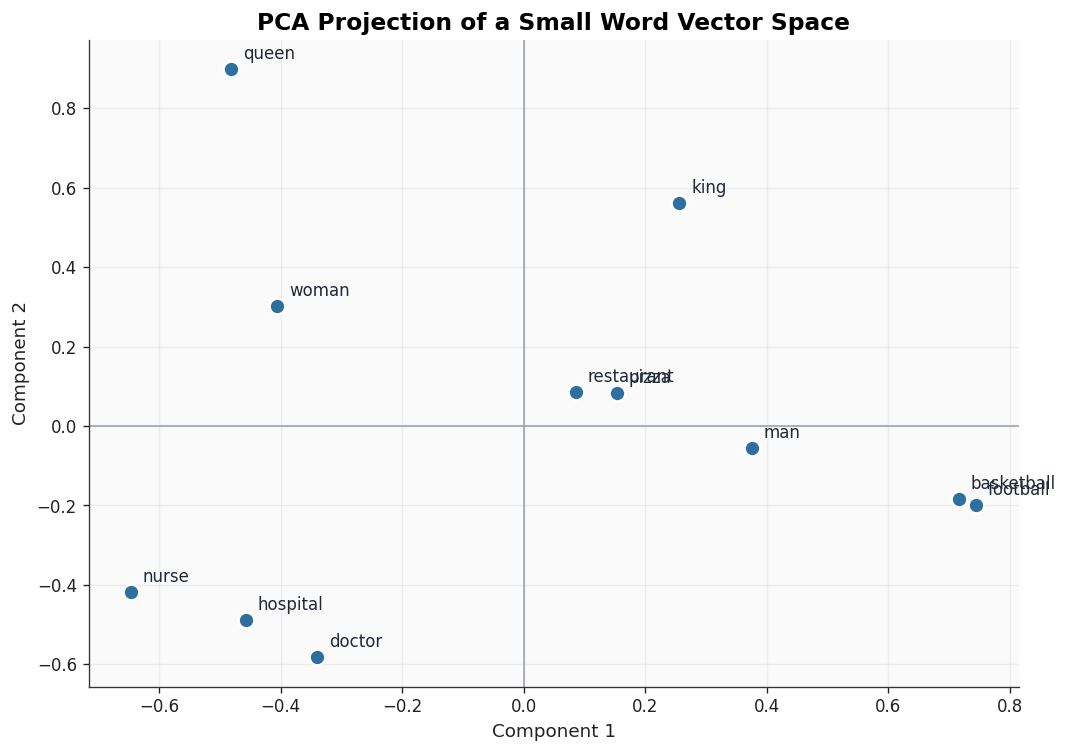

In [9]:
def plot_word_projection(projection):
    """Visualize words in a two-dimensional projected vector space."""
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(
        projection["component_1"],
        projection["component_2"],
        s=90,
        color=PRIMARY_COLOR,
        edgecolor="white",
        linewidth=1.5,
        zorder=3,
    )

    for word, row in projection.iterrows():
        ax.annotate(
            word,
            (row["component_1"], row["component_2"]),
            xytext=(7, 6),
            textcoords="offset points",
            fontsize=10,
            color="#1F2937",
        )

    ax.axhline(0, color="#9CA3AF", linewidth=1)
    ax.axvline(0, color="#9CA3AF", linewidth=1)
    ax.set_title("PCA Projection of a Small Word Vector Space")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.grid(True, alpha=0.45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()


plot_word_projection(projection_df)

## Semantic Similarity Demo

Now we can rank word pairs by cosine similarity. This gives a simple view of which words are closest in our miniature semantic space.

In [10]:
def build_similarity_matrix(vectors):
    """Build a cosine similarity matrix for all words in the vector table."""
    similarities = cosine_similarity(vectors.to_numpy())
    return pd.DataFrame(
        similarities,
        index=vectors.index,
        columns=vectors.index,
    )


similarity_df = build_similarity_matrix(vectors_df)
display(similarity_df.round(2))

,doctor,nurse,hospital,football,basketball,pizza,restaurant,king,queen,man,woman
doctor,1.00,0.89,0.97,0.29,0.27,0.19,0.25,0.40,0.21,0.52,0.22
nurse,0.89,1.00,0.97,0.15,0.14,0.18,0.26,0.20,0.42,0.23,0.55
hospital,0.97,0.97,1.00,0.21,0.20,0.20,0.27,0.30,0.30,0.38,0.38
football,0.29,0.15,0.21,1.00,1.00,0.18,0.19,0.37,0.11,0.52,0.12
basketball,0.27,0.14,0.20,1.00,1.00,0.19,0.19,0.36,0.11,0.49,0.12
pizza,0.19,0.18,0.20,0.18,0.19,1.00,0.99,0.22,0.17,0.30,0.22
restaurant,0.25,0.26,0.27,0.19,0.19,0.99,1.00,0.25,0.24,0.33,0.31
king,0.40,0.20,0.30,0.37,0.36,0.22,0.25,1.00,0.61,0.74,0.15
queen,0.21,0.42,0.30,0.11,0.11,0.17,0.24,0.61,1.00,0.15,0.74
man,0.52,0.23,0.38,0.52,0.49,0.30,0.33,0.74,0.15,1.00,0.11


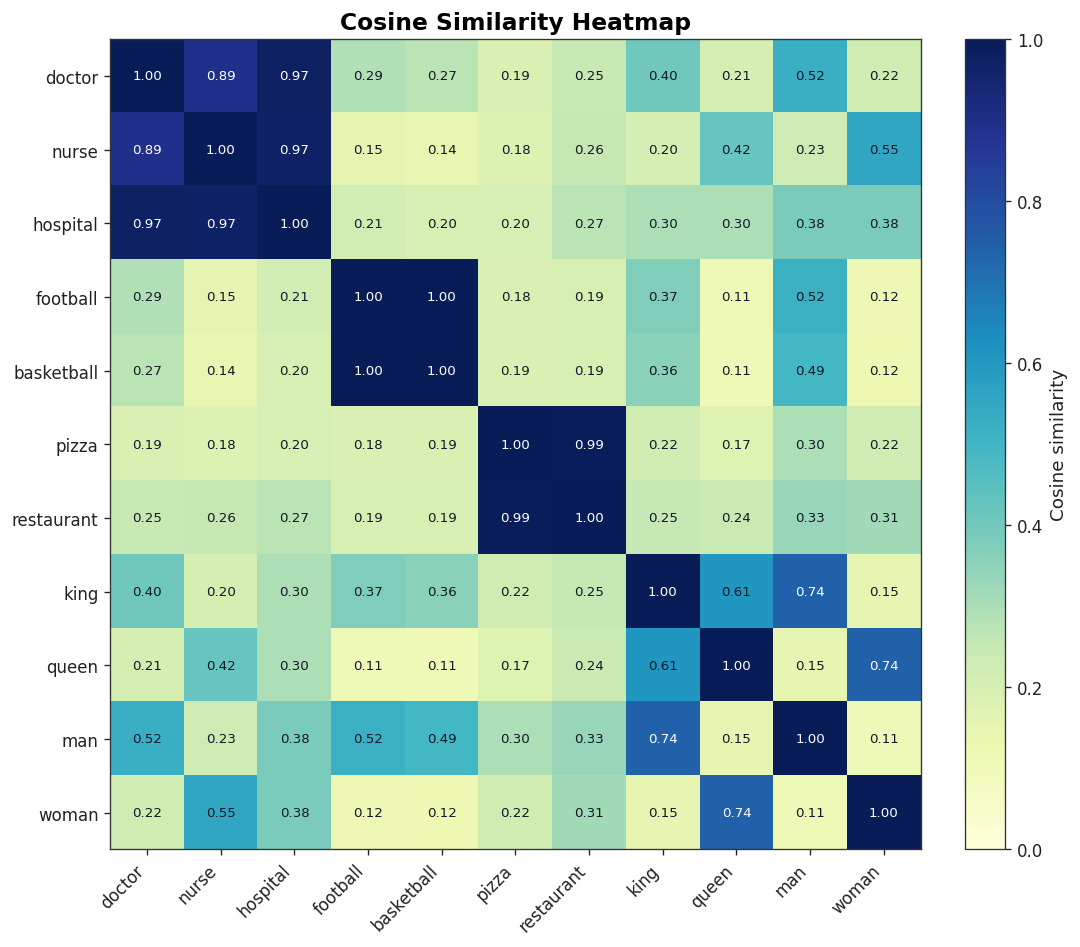

In [11]:
def plot_similarity_heatmap(similarities):
    """Plot a cosine similarity heatmap using matplotlib only."""
    labels = similarities.index.tolist()
    matrix = similarities.to_numpy()

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(matrix, cmap="YlGnBu", vmin=0, vmax=1)
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Cosine similarity")

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_title("Cosine Similarity Heatmap")

    for row_index in range(len(labels)):
        for column_index in range(len(labels)):
            value = matrix[row_index, column_index]
            text_color = "white" if value > 0.72 else "#111827"
            ax.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=8,
            )

    fig.tight_layout()
    plt.show()


plot_similarity_heatmap(similarity_df)

In [12]:
def rank_similar_words(target_word, similarities, top_n=5):
    """Return the most similar words to a target word."""
    ranked_scores = (
        similarities[target_word]
        .drop(index=target_word)
        .sort_values(ascending=False)
        .head(top_n)
    )
    return ranked_scores.reset_index().rename(
        columns={"index": "word", target_word: "cosine_similarity"}
    )


ranking_tables = []
for target_word in ["doctor", "football", "king", "pizza"]:
    ranking = rank_similar_words(target_word, similarity_df, top_n=5)
    ranking.insert(0, "query_word", target_word)
    ranking_tables.append(ranking)

similarity_ranking_df = pd.concat(ranking_tables, ignore_index=True)
display(similarity_ranking_df.round(3))

,query_word,word,cosine_similarity
0,doctor,hospital,0.974
1,doctor,nurse,0.892
2,doctor,man,0.521
3,doctor,king,0.403
4,doctor,football,0.288
5,football,basketball,1.000
6,football,man,0.517
7,football,king,0.372
8,football,doctor,0.288
9,football,hospital,0.213


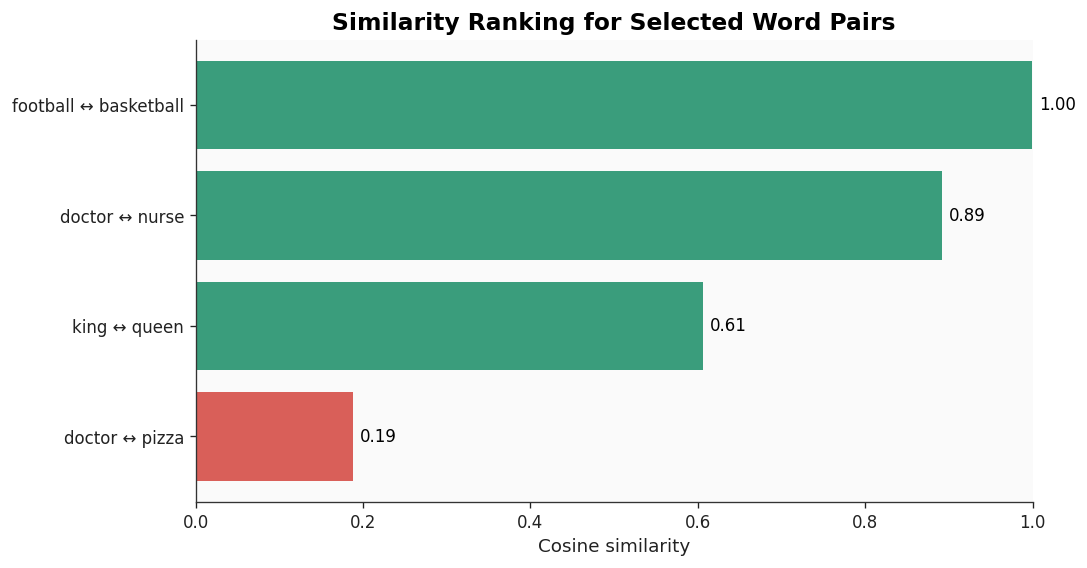

In [13]:
selected_comparisons = pd.DataFrame(
    {
        "comparison": [
            "doctor ↔ nurse",
            "football ↔ basketball",
            "king ↔ queen",
            "doctor ↔ pizza",
        ],
        "cosine_similarity": [
            calculate_cosine_similarity("doctor", "nurse"),
            calculate_cosine_similarity("football", "basketball"),
            calculate_cosine_similarity("king", "queen"),
            calculate_cosine_similarity("doctor", "pizza"),
        ],
    }
).sort_values("cosine_similarity")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    selected_comparisons["comparison"],
    selected_comparisons["cosine_similarity"],
    color=[SECONDARY_COLOR, ACCENT_COLOR, ACCENT_COLOR, ACCENT_COLOR],
)

ax.set_title("Similarity Ranking for Selected Word Pairs")
ax.set_xlabel("Cosine similarity")
ax.set_xlim(0, 1)
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

## Distance comparison

Cosine similarity and Euclidean distance can tell different stories. Cosine focuses on direction, while Euclidean distance focuses on absolute distance in the vector space.

In many NLP workflows, cosine similarity is preferred because we care about semantic orientation more than raw magnitude.

In [14]:
def calculate_euclidean_distance(word_a, word_b):
    """Calculate Euclidean distance between two word vectors."""
    difference = vectors_df.loc[word_a] - vectors_df.loc[word_b]
    return float(np.sqrt(np.sum(difference**2)))


distance_rows = []
for word_a, word_b in example_pairs:
    distance_rows.append(
        {
            "word_pair": f"{word_a} - {word_b}",
            "cosine_similarity": calculate_cosine_similarity(word_a, word_b),
            "euclidean_distance": calculate_euclidean_distance(word_a, word_b),
        }
    )

distance_df = pd.DataFrame(distance_rows)
display(distance_df.round(3))

,word_pair,cosine_similarity,euclidean_distance
0,doctor - nurse,0.892,0.518
1,football - basketball,1.000,0.060
2,king - queen,0.606,1.202
3,doctor - pizza,0.188,1.364


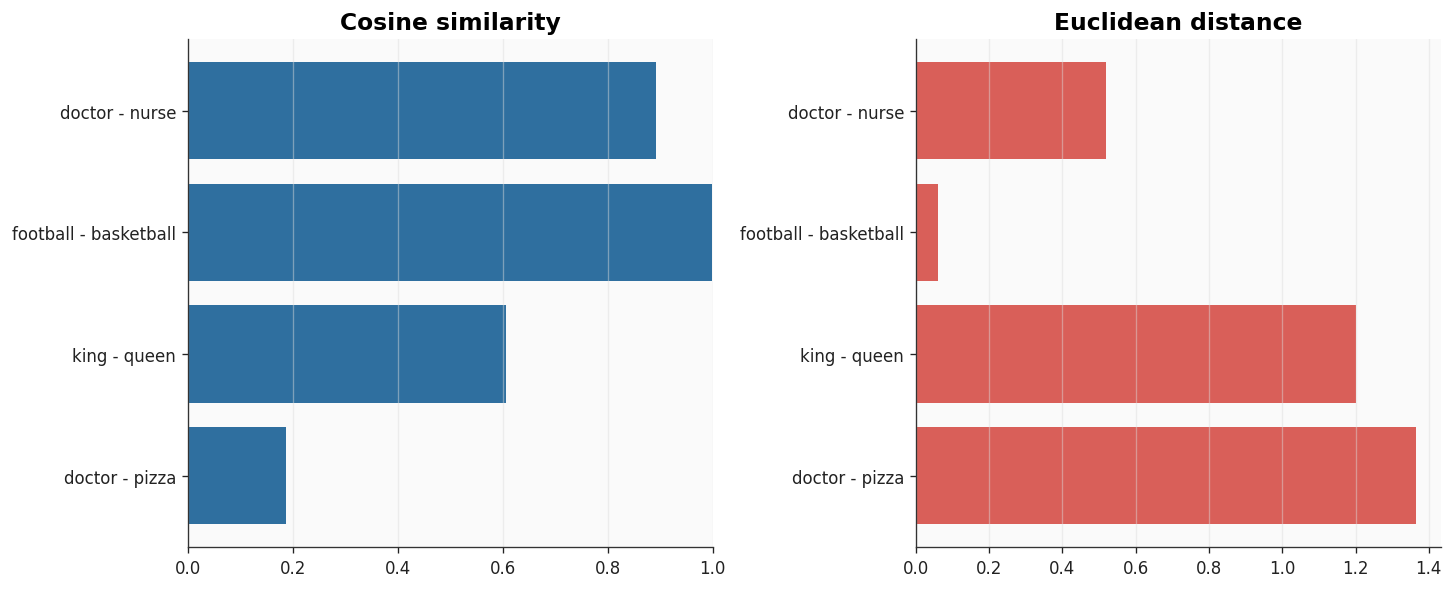

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

axes[0].barh(
    distance_df["word_pair"],
    distance_df["cosine_similarity"],
    color=PRIMARY_COLOR,
)
axes[0].set_title("Cosine similarity")
axes[0].set_xlim(0, 1)
axes[0].invert_yaxis()

axes[1].barh(
    distance_df["word_pair"],
    distance_df["euclidean_distance"],
    color=SECONDARY_COLOR,
)
axes[1].set_title("Euclidean distance")
axes[1].invert_yaxis()

for axis in axes:
    axis.grid(axis="x", alpha=0.45)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.show()

## Analogy Concept

One of the most famous intuitions behind word vectors is:

\[
\text{King} - \text{Man} + \text{Woman} \approx \text{Queen}
\]

The idea is that vector directions can encode relationships. If a model learns a direction that roughly corresponds to gender, then subtracting `man` from `king` and adding `woman` should move the vector toward `queen`.

This notebook does not train Word2Vec yet. The goal here is only to understand the geometric intuition.

The manually designed vector space recovers the intended result: the transformed vector is closest to `queen`. Real models learn these patterns from statistical regularities in large corpora rather than from manually assigned dimensions.

In [16]:
analogy_vector = (
    vectors_df.loc["king"].to_numpy()
    - vectors_df.loc["man"].to_numpy()
    + vectors_df.loc["woman"].to_numpy()
)

analogy_scores = cosine_similarity(
    analogy_vector.reshape(1, -1),
    vectors_df.to_numpy(),
).ravel()

analogy_results = (
    pd.DataFrame(
        {
            "word": vectors_df.index,
            "similarity_to_king_minus_man_plus_woman": analogy_scores,
        }
    )
    .sort_values(
        "similarity_to_king_minus_man_plus_woman",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(analogy_results.round(3))

,word,similarity_to_king_minus_man_plus_woman
0,queen,0.999
1,woman,0.757
2,king,0.569
3,nurse,0.421
4,hospital,0.289
5,restaurant,0.233
6,doctor,0.190
7,pizza,0.165
8,man,0.111
9,basketball,0.091


## Where do Word Vectors come from?

**Word2Vec** learns word vectors by predicting words from nearby context or predicting context from a target word. It showed that useful semantic relationships can emerge from a relatively simple neural training objective.

**GloVe** learns vectors from global word co-occurrence statistics. It combines matrix factorization ideas with distributional semantics: words that appear in similar contexts receive similar representations.

**FastText** extends word vectors by representing words through character n-grams. This helps with rare words, misspellings, and morphologically rich languages because the model can use subword information.

The next notebook will move from conceptual vectors to real embedding models such as Word2Vec, GloVe, and FastText.

## Real-world Applications

Dense word representations became important because they improved many practical NLP systems:

- **Semantic Search**: retrieve documents that match meaning, not just exact keywords.
- **Recommendation Systems**: recommend similar products, articles, jobs, or media items.
- **Chatbots**: match user messages to intents even when wording varies.
- **Question Answering**: connect questions with passages that express relevant meaning.
- **Machine Translation**: map words and phrases across languages using semantic structure.
- **Document Retrieval**: rank documents by conceptual relevance.
- **RAG Systems**: retrieve relevant context before generating an answer with a language model.

## Advantages

Word vectors offer several benefits over purely sparse representations:

- they capture semantic similarity,
- they reduce dimensionality compared with vocabulary-sized vectors,
- they improve generalization to related words,
- they support vector operations such as similarity search and analogies,
- they provide reusable features for downstream machine learning models.

## Limitations

Classic word vectors also have important limitations.

The biggest issue is that each word usually receives **one vector**, regardless of context. This means the same representation is used for different meanings of the same word.

For example:

- `bank` can refer to a financial institution,
- `bank` can also refer to the side of a river.

A single static vector cannot fully distinguish these meanings. Later, Transformer-based models solve this problem with contextual embeddings, where the representation of a word changes depending on the sentence.

## Final Summary

In this notebook, we moved from sparse representations toward dense semantic spaces.

You learned that:

1. TF-IDF is useful, but it depends heavily on exact word overlap.
2. Sparse vectors struggle with synonyms and semantic similarity.
3. Word vectors represent words as dense fixed-length numerical vectors.
4. Cosine similarity measures semantic closeness by comparing vector direction.
5. PCA-style projection can help visualize word relationships.
6. Vector arithmetic gives intuition for analogies such as `king - man + woman ≈ queen`.
7. Static word vectors are powerful but limited because they are not context-aware.

Dense word vectors are an important stepping stone toward modern embeddings and Transformer-based NLP systems.

## Next Notebook

➡️ Next: Word Embeddings

The next notebook will move from the concept of word vectors to real embedding models such as Word2Vec, GloVe, and FastText.